In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [60]:
df = pd.read_csv("Europe Sales Records.csv")     
df.head(5)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45,31.79,226716.10,151892.62,74823.48
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,10/14/2013,919133651,11/4/2013,927,109.28,35.84,101302.56,33223.68,68078.88
2,Europe,Austria,Cereal,Offline,C,8/13/2014,987410676,9/6/2014,5616,205.70,117.11,1155211.20,657689.76,497521.44
3,Europe,Bulgaria,Office Supplies,Online,L,10/31/2010,672330081,11/29/2010,6266,651.21,524.96,4080481.86,3289399.36,791082.50
4,Europe,Estonia,Fruits,Online,L,9/28/2016,579463422,11/1/2016,4958,9.33,6.92,46258.14,34309.36,11948.78


In [61]:
print("Number of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

Number of Rows: 1330
Number of Columns: 14


In [62]:
df.columns 

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='str')

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          1330 non-null   str    
 1   Country         1330 non-null   str    
 2   Item Type       1330 non-null   str    
 3   Sales Channel   1330 non-null   str    
 4   Order Priority  1330 non-null   str    
 5   Order Date      1330 non-null   str    
 6   Order ID        1330 non-null   int64  
 7   Ship Date       1330 non-null   str    
 8   Units Sold      1330 non-null   int64  
 9   Unit Price      1330 non-null   float64
 10  Unit Cost       1330 non-null   float64
 11  Total Revenue   1330 non-null   float64
 12  Total Cost      1330 non-null   float64
 13  Total Profit    1330 non-null   float64
dtypes: float64(5), int64(2), str(7)
memory usage: 145.6 KB


In [64]:
df.isnull().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.dtypes

Region                str
Country               str
Item Type             str
Sales Channel         str
Order Priority        str
Order Date            str
Order ID            int64
Ship Date             str
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

In [67]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [68]:
df.dtypes

Region                       str
Country                      str
Item Type                    str
Sales Channel                str
Order Priority               str
Order Date        datetime64[us]
Order ID                   int64
Ship Date         datetime64[us]
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
Total Revenue            float64
Total Cost               float64
Total Profit             float64
dtype: object

In [69]:
df["Order Year"] = df["Order Date"].dt.year

df["Order Month"] = df["Order Date"].dt.month

df["Order Month Name"] = df["Order Date"].dt.month_name()

In [70]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order Year,Order Month,Order Month Name
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48,2011,9,September
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88,2013,10,October
2,Europe,Austria,Cereal,Offline,C,2014-08-13,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44,2014,8,August
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50,2010,10,October
4,Europe,Estonia,Fruits,Online,L,2016-09-28,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78,2016,9,September


In [71]:
print("Total Revenue:", df["Total Revenue"].sum())

print("Total Cost:", df["Total Cost"].sum())

print("Total Profit:", df["Total Profit"].sum())

print("Total Units Sold:", df["Units Sold"].sum())

Total Revenue: 1703622398.11
Total Cost: 1201946349.79
Total Profit: 501676048.32000005
Total Units Sold: 6582322


In [72]:
# to arrange no. nicly
print("Total Revenue: ${:,.2f}".format(df["Total Revenue"].sum()))  

print("Total Cost: ${:,.2f}".format(df["Total Cost"].sum()))

print("Total Profit: ${:,.2f}".format(df["Total Profit"].sum()))

print("Total Units Sold: {:,}".format(df["Units Sold"].sum()))

Total Revenue: $1,703,622,398.11
Total Cost: $1,201,946,349.79
Total Profit: $501,676,048.32
Total Units Sold: 6,582,322


In [73]:
# sort country according to Total revenue
country_revenue = (
    df.groupby("Country")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
Kosovo                    53833142.79
Czech Republic            53543932.14
Ukraine                   53252317.54
Bosnia and Herzegovina    50117508.49
Macedonia                 49222085.25
San Marino                47883708.48
Andorra                   47756693.17
Portugal                  47172189.84
Malta                     47145320.81
Russia                    46051659.81
Name: Total Revenue, dtype: float64

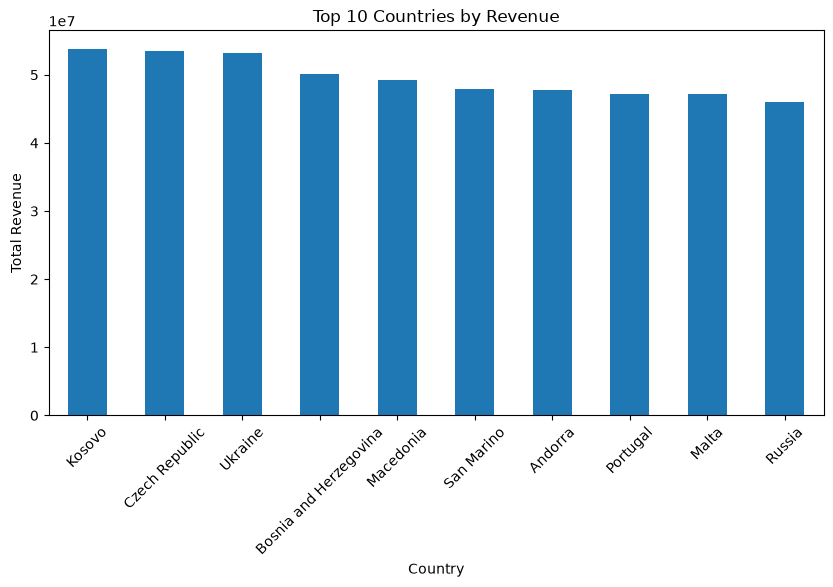

In [74]:
# plot graph 
country_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

In [75]:
# sort by total profit
item_profit = (
    df.groupby("Item Type")["Total Profit"]
    .sum()
    .sort_values(ascending=False)
)

item_profit

Item Type
Cosmetics          92723306.17
Office Supplies    77977176.25
Household          72962466.77
Baby Food          53940997.16
Clothes            43431314.40
Cereal             41255034.15
Vegetables         36776002.72
Meat               30509107.20
Snacks             27027422.40
Personal Care      14045628.80
Beverages           9601662.78
Fruits              1425929.52
Name: Total Profit, dtype: float64

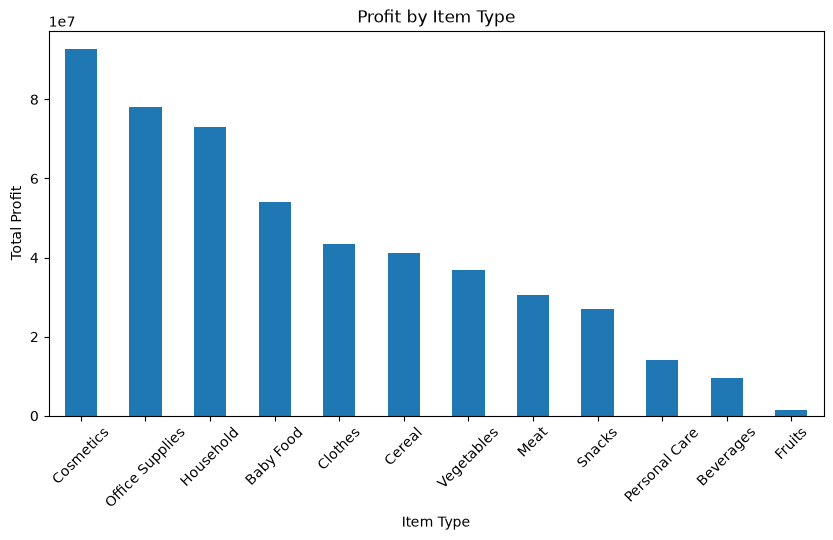

In [76]:
item_profit.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Profit by Item Type")

plt.xlabel("Item Type")

plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.show()

In [77]:
# Revenue of each month of each year 
monthly_revenue = (
    df.groupby(["Order Year", "Order Month"])["Total Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Order Year,Order Month,Total Revenue
0,2010,1,21115354.48
1,2010,2,19853023.20
2,2010,3,8474747.19
3,2010,4,10058016.05
4,2010,5,20304725.59


In [78]:
# New date column 
monthly_revenue["Date"] = pd.to_datetime(
    monthly_revenue["Order Year"].astype(str)
    + "-"
    + monthly_revenue["Order Month"].astype(str)
    + "-01"
)

monthly_revenue.head()

,Order Year,Order Month,Total Revenue,Date
0,2010,1,21115354.48,2010-01-01
1,2010,2,19853023.20,2010-02-01
2,2010,3,8474747.19,2010-03-01
3,2010,4,10058016.05,2010-04-01
4,2010,5,20304725.59,2010-05-01


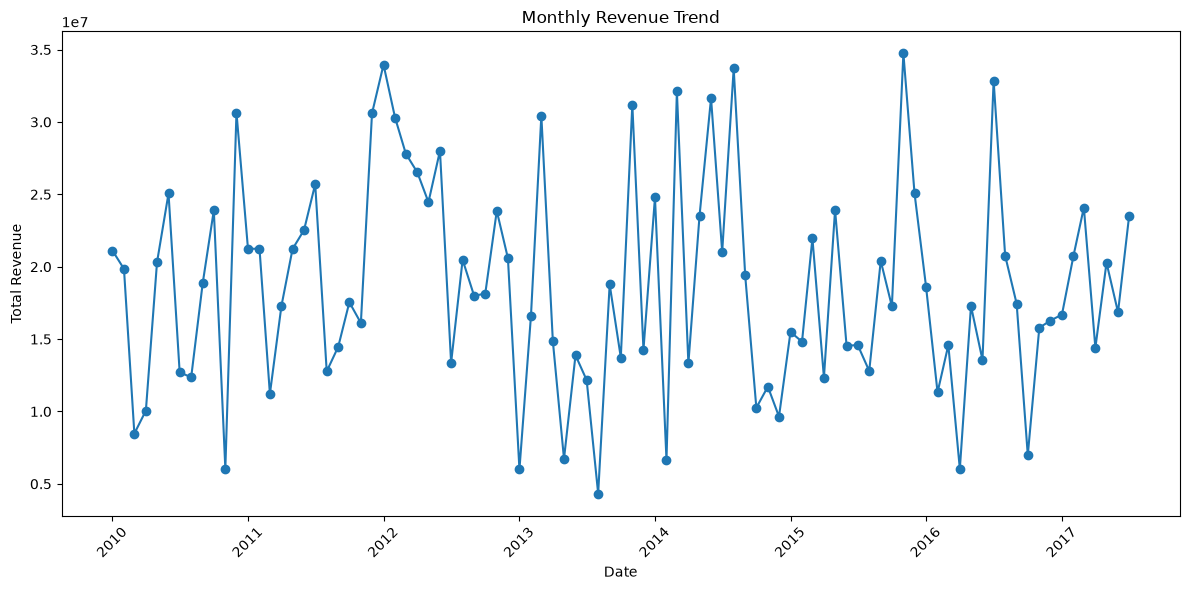

In [79]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Date"],
    monthly_revenue["Total Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Date")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [80]:
region_revenue = (
    df.groupby("Region")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
Europe    1.703622e+09
Name: Total Revenue, dtype: float64

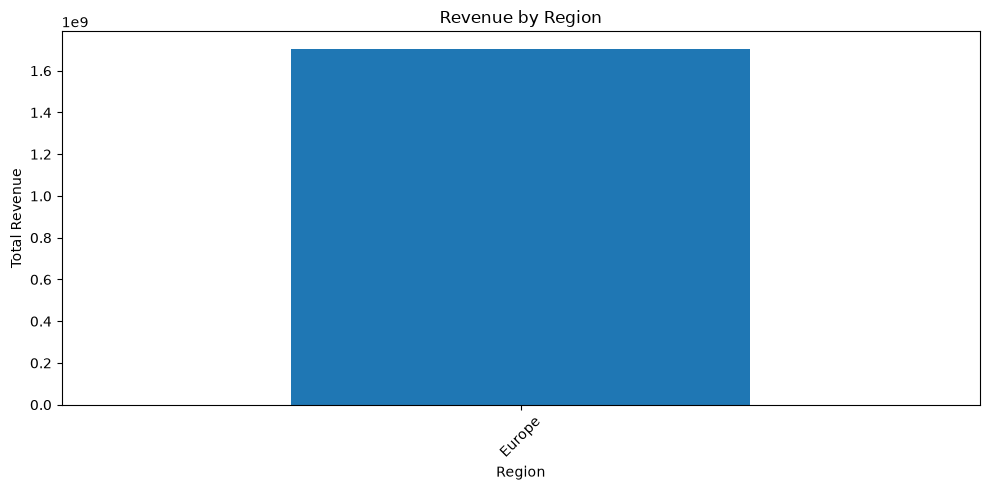

In [81]:
plt.figure(figsize=(10, 5))

region_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [82]:
Country_revenue = (
    df.groupby("Country")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
)

Country_revenue

Country
Kosovo                    53833142.79
Czech Republic            53543932.14
Ukraine                   53252317.54
Bosnia and Herzegovina    50117508.49
Macedonia                 49222085.25
San Marino                47883708.48
Andorra                   47756693.17
Portugal                  47172189.84
Malta                     47145320.81
Russia                    46051659.81
Slovakia                  42940998.32
Hungary                   42408249.12
Serbia                    42193537.74
France                    39362112.15
Slovenia                  38892531.27
Latvia                    38722084.15
Greece                    38699541.70
Bulgaria                  38161555.70
Germany                   38055087.56
Armenia                   37519840.21
Italy                     35878352.12
Austria                   35740871.49
Sweden                    35482128.02
Romania                   34286150.85
Belarus                   34236260.77
Poland                    33805403.22
Luxe

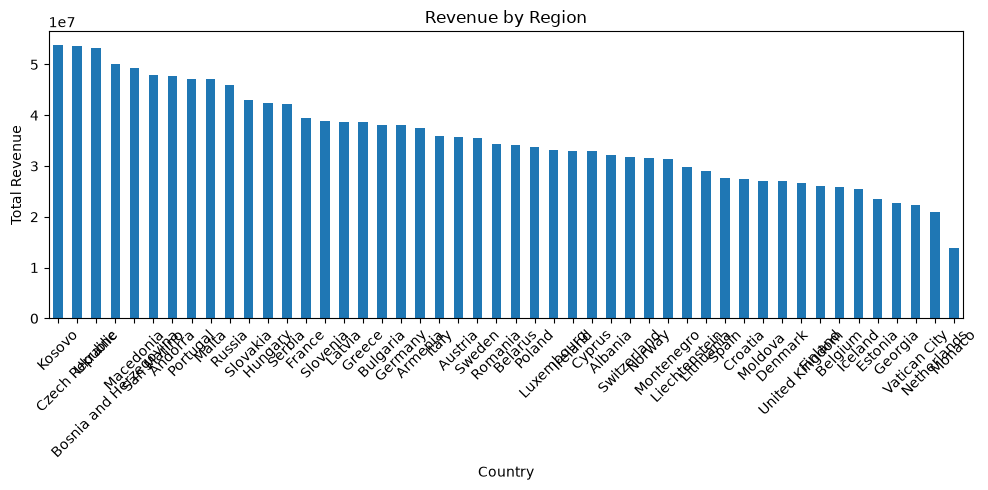

In [83]:
plt.figure(figsize=(10, 5))

Country_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Region")

plt.xlabel("Country")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [84]:
channel_revenue = (
    df.groupby("Sales Channel")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
)

channel_revenue

Sales Channel
Offline    8.732536e+08
Online     8.303688e+08
Name: Total Revenue, dtype: float64

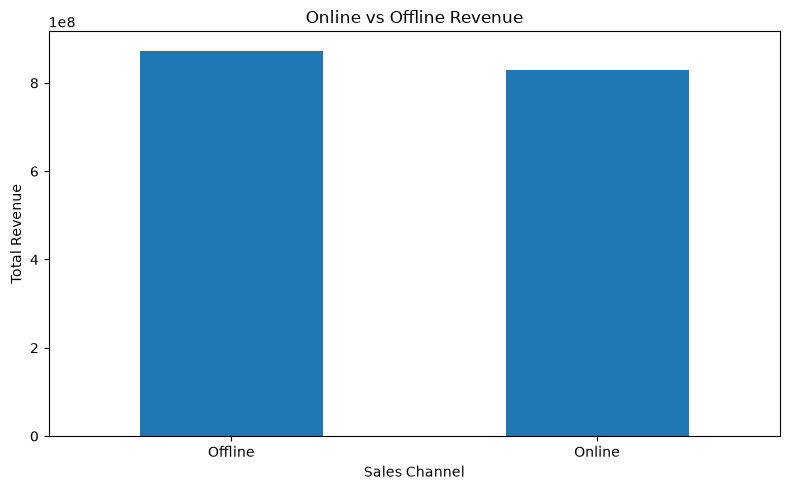

In [85]:
plt.figure(figsize=(8, 5))

channel_revenue.plot(
    kind="bar"
)

plt.title("Online vs Offline Revenue")

plt.xlabel("Sales Channel")

plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [86]:
product_units = (
    df.groupby("Item Type")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

product_units

Item Type
Office Supplies    617641
Beverages          613133
Fruits             591672
Clothes            591385
Vegetables         582544
Baby Food          562706
Personal Care      560480
Meat               533376
Cosmetics          533291
Snacks             490160
Cereal             465685
Household          440249
Name: Units Sold, dtype: int64

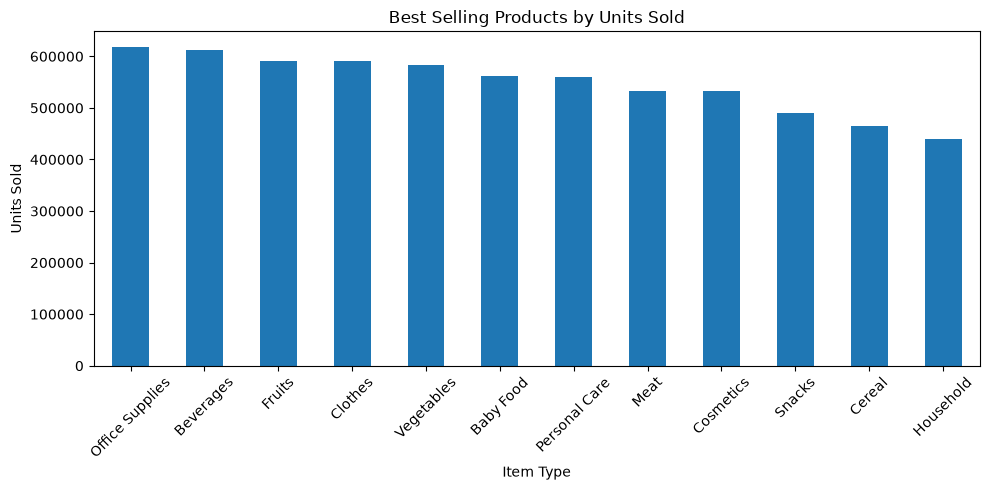

In [87]:
plt.figure(figsize=(10, 5))

product_units.plot(
    kind="bar"
)

plt.title("Best Selling Products by Units Sold")

plt.xlabel("Item Type")

plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [88]:
# to get Profit Margin of each Item
df["Profit Margin"] = (
    df["Total Profit"] / df["Total Revenue"]
) * 100

df[[
    "Item Type",
    "Total Revenue",
    "Total Profit",
    "Profit Margin"
]].head()

,Item Type,Total Revenue,Total Profit,Profit Margin
0,Beverages,226716.10,74823.48,33.003161
1,Clothes,101302.56,68078.88,67.203514
2,Cereal,1155211.20,497521.44,43.067574
3,Office Supplies,4080481.86,791082.50,19.386987
4,Fruits,46258.14,11948.78,25.830654


In [89]:
# Group Item with Profit Margin
item_profit_margin = (
    df.groupby("Item Type")["Profit Margin"]
    .mean()
    .sort_values(ascending=False)
)

item_profit_margin

Item Type
Clothes            67.203514
Cereal             43.067574
Vegetables         40.977541
Cosmetics          39.768984
Baby Food          37.550924
Snacks             36.138419
Beverages          33.003161
Personal Care      30.661936
Fruits             25.830654
Household          24.799856
Office Supplies    19.386987
Meat               13.558036
Name: Profit Margin, dtype: float64

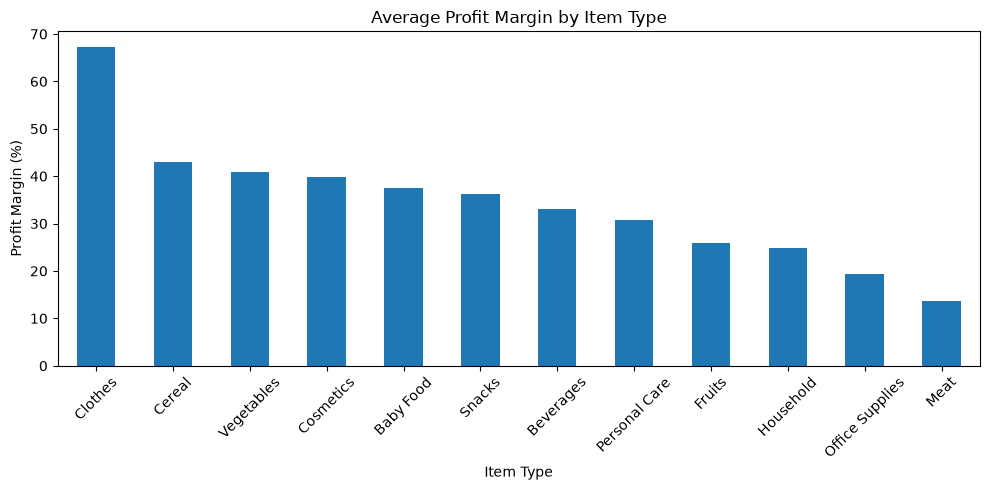

In [90]:
plt.figure(figsize=(10, 5))

item_profit_margin.plot(
    kind="bar"
)

plt.title("Average Profit Margin by Item Type")

plt.xlabel("Item Type")

plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [91]:
# time needed to recive the order
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[[
    "Order Date",
    "Ship Date",
    "Shipping Days"
]].head()

,Order Date,Ship Date,Shipping Days
0,2011-09-12,2011-09-29,17
1,2013-10-14,2013-11-04,21
2,2014-08-13,2014-09-06,24
3,2010-10-31,2010-11-29,29
4,2016-09-28,2016-11-01,34


In [92]:
region_shipping = (
    df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values(ascending=False)
)

region_shipping

Region
Europe    24.77594
Name: Shipping Days, dtype: float64

In [93]:
Country_shipping = (
    df.groupby("Country")["Shipping Days"]
    .mean()
    .sort_values(ascending=False)
)

Country_shipping

Country
Hungary                   32.640000
Georgia                   29.695652
Austria                   28.500000
Slovakia                  28.466667
Luxembourg                27.750000
Lithuania                 27.560000
Poland                    27.464286
Russia                    27.375000
Monaco                    26.846154
Bulgaria                  26.800000
Montenegro                26.678571
Netherlands               26.625000
Belgium                   26.538462
France                    26.423077
Andorra                   26.275000
Finland                   26.217391
Albania                   26.190476
Armenia                   26.172414
Spain                     26.153846
Moldova                   26.083333
Bosnia and Herzegovina    26.060606
Ukraine                   25.757576
Belarus                   25.250000
Czech Republic            25.225806
Italy                     25.200000
Sweden                    25.137931
Romania                   24.941176
Portugal            

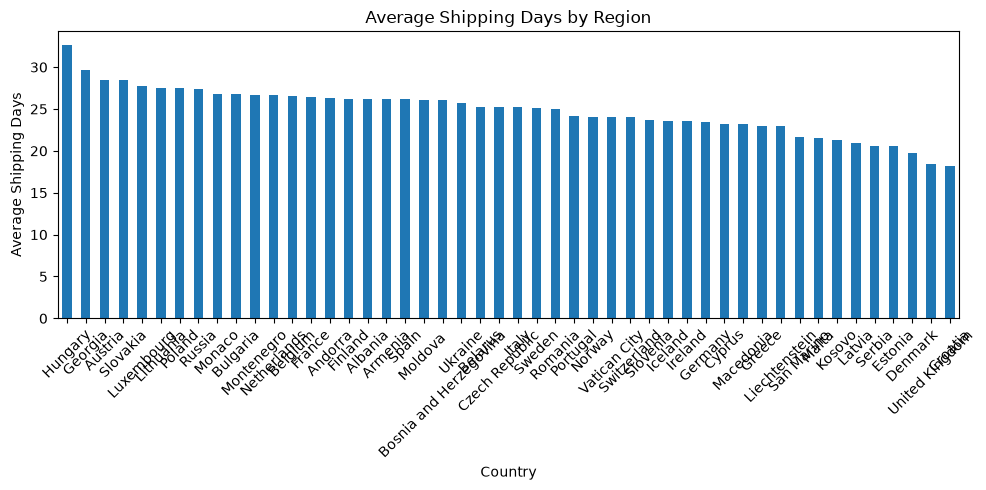

In [94]:
plt.figure(figsize=(10, 5))

Country_shipping.plot(
    kind="bar"
)

plt.title("Average Shipping Days by Region")

plt.xlabel("Country")

plt.ylabel("Average Shipping Days")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [95]:
# Top Country as per revenue
top_country = (
    df.groupby("Country")["Total Revenue"]
    .sum()
    .idxmax()
)

top_country

'Kosovo'

In [96]:
# Actual revenue of top country
top_country_revenue = (
    df.groupby("Country")["Total Revenue"]
    .sum()
    .max()
)

top_country_revenue

np.float64(53833142.79)

In [97]:
print(
    f"🏆 The country with the highest revenue is "
    f"{top_country} with total revenue of "
    f"${top_country_revenue:,.2f}"
)

🏆 The country with the highest revenue is Kosovo with total revenue of $53,833,142.79


In [98]:
best_product = (
    df.groupby("Item Type")["Units Sold"]
    .sum()
    .idxmax()
)

best_product

'Office Supplies'

In [99]:
best_product_units = (
    df.groupby("Item Type")["Units Sold"]
    .sum()
    .max()
)

best_product_units

np.int64(617641)

In [100]:
print(
    f"📦 The best-selling product is "
    f"{best_product} with "
    f"{best_product_units:,} units sold."
)

📦 The best-selling product is Office Supplies with 617,641 units sold.


In [101]:
most_profitable_product = (
    df.groupby("Item Type")["Total Profit"]
    .sum()
    .idxmax()
)

most_profitable_product

'Cosmetics'

In [102]:
highest_profit = (
    df.groupby("Item Type")["Total Profit"]
    .sum()
    .max()
)

highest_profit

np.float64(92723306.17)

In [103]:
print(
    f"💰 The most profitable product is "
    f"{most_profitable_product} with a total profit of "
    f"${highest_profit:,.2f}"
)

💰 The most profitable product is Cosmetics with a total profit of $92,723,306.17


In [104]:
best_region = (
    df.groupby("Region")["Total Revenue"]
    .sum()
    .idxmax()
)

best_region

'Europe'

In [105]:
best_region_revenue = (
    df.groupby("Region")["Total Revenue"]
    .sum()
    .max()
)

print(
    f"🌍 The best performing region is "
    f"{best_region} with total revenue of "
    f"${best_region_revenue:,.2f}"
)

🌍 The best performing region is Europe with total revenue of $1,703,622,398.11


In [106]:
best_channel = (
    df.groupby("Sales Channel")["Total Revenue"]
    .sum()
    .idxmax()
)

best_channel

'Offline'

In [107]:
best_channel_revenue = (
    df.groupby("Sales Channel")["Total Revenue"]
    .sum()
    .max()
)

print(
    f"💻 The best performing sales channel is "
    f"{best_channel} with revenue of "
    f"${best_channel_revenue:,.2f}"
)

💻 The best performing sales channel is Offline with revenue of $873,253,613.78


In [108]:
# All Output coolect together
print("=" * 60)
print("🤖 AI BUSINESS INTELLIGENCE COPILOT - INSIGHTS")
print("=" * 60)

print(f"\n🏆 Top Revenue Country: {top_country}")
print(f"   Revenue: ${top_country_revenue:,.2f}")

print(f"\n📦 Best Selling Product: {best_product}")
print(f"   Units Sold: {best_product_units:,}")

print(f"\n💰 Most Profitable Product: {most_profitable_product}")
print(f"   Total Profit: ${highest_profit:,.2f}")

print(f"\n🌍 Best Performing Region: {best_region}")
print(f"   Revenue: ${best_region_revenue:,.2f}")

print(f"\n💻 Best Sales Channel: {best_channel}")
print(f"   Revenue: ${best_channel_revenue:,.2f}")

print("\n" + "=" * 60)

🤖 AI BUSINESS INTELLIGENCE COPILOT - INSIGHTS

🏆 Top Revenue Country: Kosovo
   Revenue: $53,833,142.79

📦 Best Selling Product: Office Supplies
   Units Sold: 617,641

💰 Most Profitable Product: Cosmetics
   Total Profit: $92,723,306.17

🌍 Best Performing Region: Europe
   Revenue: $1,703,622,398.11

💻 Best Sales Channel: Offline
   Revenue: $873,253,613.78



In [109]:
# create copilot 
def business_copilot(question):

    question = question.lower()

    if "highest revenue country" in question:

        answer = (
            f"The country with the highest revenue is "
            f"{top_country} with total revenue of "
            f"${top_country_revenue:,.2f}"
        )

        return answer

In [110]:
business_copilot(
    "highest revenue country"
)

'The country with the highest revenue is Kosovo with total revenue of $53,833,142.79'

In [111]:
def business_copilot(question):

    question = question.lower()

    
    # Highest Revenue Country
    
    if "country" in question and "revenue" in question:

        return (
            f"🏆 The country with the highest revenue is "
            f"{top_country} with total revenue of "
            f"${top_country_revenue:,.2f}"
        )


    # Best Selling Product

    elif "best selling product" in question:

        return (
            f"📦 The best-selling product is "
            f"{best_product} with "
            f"{best_product_units:,} units sold."
        )


    # Most Profitable Product

    elif "most profitable product" in question:

        return (
            f"💰 The most profitable product is "
            f"{most_profitable_product} with total profit of "
            f"${highest_profit:,.2f}"
        )


    # Best Region

    elif "best region" in question:

        return (
            f"🌍 The best-performing region is "
            f"{best_region} with total revenue of "
            f"${best_region_revenue:,.2f}"
        )


    # Best Sales Channel

    elif "sales channel" in question:

        return (
            f"💻 The best-performing sales channel is "
            f"{best_channel} with revenue of "
            f"${best_channel_revenue:,.2f}"
        )


    else:

        return (
            "Sorry, I don't understand this question yet."
        )

In [112]:
business_copilot(
    "Which country has the highest revenue?"
)


'🏆 The country with the highest revenue is Kosovo with total revenue of $53,833,142.79'

In [113]:
business_copilot(
    "What is the best selling product?"
)

'📦 The best-selling product is Office Supplies with 617,641 units sold.'

In [114]:
business_copilot(
    "Which is the most profitable product?"
)

'💰 The most profitable product is Cosmetics with total profit of $92,723,306.17'

In [115]:
business_copilot(
    "Which is the best region?"
)

'🌍 The best-performing region is Europe with total revenue of $1,703,622,398.11'

In [116]:
business_copilot(
    "Which sales channel performs best?"
)

'💻 The best-performing sales channel is Offline with revenue of $873,253,613.78'

In [117]:
pip install google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [118]:
 pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [119]:
pip install google-genai python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [120]:
import os
from dotenv import load_dotenv
from google import genai

# Load API key from .env file
load_dotenv()

# Get API key
api_key = os.getenv("GEMINI_API_KEY")

# Connect to Gemini
client = genai.Client(api_key=api_key)

print("Gemini connected successfully! 🎉")

Gemini connected successfully! 🎉


In [121]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="Explain machine learning in one simple sentence."
)

print(response.text)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Machine learning is a way of teaching computers to learn from data and make decisions or predictions on their own, without being explicitly programmed.


In [122]:
dataset_info = f"""
You are an AI Business Intelligence Copilot.

You are analyzing a Europe Sales Records dataset.

The dataset has the following columns:

{df.columns.tolist()}

Here are the first 5 rows of the dataset:

{df.head().to_string()}

Important information about the dataset:

- Total Revenue represents the money earned from sales.
- Total Cost represents the cost of products sold.
- Total Profit represents the profit earned.
- Units Sold represents the number of products sold.
- Region represents the geographical region.
- Country represents the country where the order was placed.
- Item Type represents the product category.
- Sales Channel represents Online or Offline sales.
"""

In [123]:
print(dataset_info)


You are an AI Business Intelligence Copilot.

You are analyzing a Europe Sales Records dataset.

The dataset has the following columns:

['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit', 'Order Year', 'Order Month', 'Order Month Name', 'Profit Margin', 'Shipping Days']

Here are the first 5 rows of the dataset:

   Region                 Country        Item Type Sales Channel Order Priority Order Date   Order ID  Ship Date  Units Sold  Unit Price  Unit Cost  Total Revenue  Total Cost  Total Profit  Order Year  Order Month Order Month Name  Profit Margin  Shipping Days
0  Europe          Czech Republic        Beverages       Offline              C 2011-09-12  478051030 2011-09-29        4778       47.45      31.79      226716.10   151892.62      74823.48        2011            9        September      33.003161             17
1  Europe  Bosni

In [124]:
question = "Based on the dataset, what should the company focus on to improve business performance?"

prompt = f"""
{dataset_info}

User Question:
{question}

Give a clear and professional business answer.

Important:
Only use the information provided in the dataset.
Do not make up data.
Explain your answer in simple language.
"""

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response.text)

Based on the structure and sample data of the **Europe Sales Records dataset**, the company should focus on the following key areas to improve business performance:

---

### 1. **Prioritize High-Margin Product Categories**
* **Observation:** Profit margins vary significantly depending on the `Item Type`. For example, in the sample data, **Clothes** yield a high profit margin of **~67%**, whereas **Office Supplies** yield a much lower profit margin of **~19%**.
* **Action:** Shift marketing and sales efforts toward promoting high-margin item types (like Clothes and Cereal) to generate higher total profit without necessarily increasing operating costs.

---

### 2. **Reduce Shipping Days (Fulfillment Efficiency)**
* **Observation:** The `Shipping Days` metric shows long delivery windows ranging from **17 to 34 days** between the `Order Date` and `Ship Date`.
* **Action:** Optimize order processing and supply chain logistics to lower shipping times. Faster fulfillment improves customer s

In [125]:
dataset_summary = f"""
Dataset Name: Europe Sales Records

Columns:
{df.columns.tolist()}

Total Rows: {df.shape[0]}

Total Columns: {df.shape[1]}

Available Business Metrics:
- Total Revenue
- Total Cost
- Total Profit
- Units Sold
- Profit Margin
- Shipping Days

Categories Available:
- Region
- Country
- Item Type
- Sales Channel
- Order Priority
- Order Year
- Order Month
"""


In [126]:
def explain_with_ai(question, result):

    prompt = f"""
You are an AI Business Intelligence Copilot.

Dataset Information:
{dataset_summary}

User Question:
{question}

Actual Result Calculated Using Pandas:
{result}

Instructions:
1. Answer the user's question based ONLY on the actual result.
2. Do not make up numbers.
3. Give a clear business explanation.
4. Keep the answer simple and professional.
5. Add one useful business insight.

Now provide the answer.
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    return response.text

In [127]:
top_5_profit_countries = (
    df.groupby("Country")["Total Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_profit_countries

Country
Andorra       15410036.63
Ukraine       14804925.74
Malta         14610127.88
Kosovo        14409145.45
San Marino    13792992.81
Name: Total Profit, dtype: float64

In [128]:
question = "Which 5 countries generated the highest total profit?"

ai_answer = explain_with_ai(
    question,
    top_5_profit_countries.to_string()
)

print(ai_answer)

The top 5 countries that generated the highest total profit in Europe are:

1. **Andorra:** $15,410,036.63
2. **Ukraine:** $14,804,925.74
3. **Malta:** $14,610,127.88
4. **Kosovo:** $14,409,145.45
5. **San Marino:** $13,792,992.81

---

### **Business Summary**
These five markets represent the most profitable countries in the European region sales records, with **Andorra** leading as the overall top contributor generating over $15.41 million in total profit. Combined, these top 5 countries generated **$73,027,228.51** in total profit.

### **Key Business Insight**
Four out of the top five most profitable countries (Andorra, Malta, Kosovo, and San Marino) are smaller European nations/microstates. This indicates that overall market size or population is not the primary driver of profitability in this region. Instead, high total profits in these markets are likely driven by higher-margin product mixes or larger bulk order sizes per deal. Business teams should analyze the specific item typ

In [129]:
channel_profit = (
    df.groupby("Sales Channel")["Total Profit"]
    .sum()
    .sort_values(ascending=False)
)

channel_profit

Sales Channel
Offline    2.537081e+08
Online     2.479679e+08
Name: Total Profit, dtype: float64

In [130]:
question = "Compare Online and Offline sales based on total profit."

ai_answer = explain_with_ai(
    question,
    channel_profit.to_string()
)

print(ai_answer)

Based on the dataset, here is the comparison of Total Profit between the **Online** and **Offline** sales channels:

### **Summary of Results:**
* **Offline Total Profit:** **$253,708,100** (~$253.71 Million)
* **Online Total Profit:** **$247,967,900** (~$247.97 Million)

---

### **Business Explanation:**
The **Offline** sales channel generated **$5,740,200** (approx. **2.3%**) more in total profit compared to the **Online** sales channel. Overall, both channels are performing very similarly, contributing nearly equal shares to total business profitability.

---

### **Business Insight:**
Since profit contributions are almost evenly split, the business maintains a healthy multi-channel revenue stream. However, because digital sales typically carry lower physical overhead, management should review channel-specific **Profit Margins** and customer acquisition costs. Targeted digital initiatives could easily close the $5.74M gap and boost overall net margins for the Online channel.


In [131]:
top_products_revenue = (
    df.groupby("Item Type")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products_revenue

Item Type
Office Supplies    4.022140e+08
Household          2.942052e+08
Cosmetics          2.331548e+08
Meat               2.250260e+08
Baby Food          1.436476e+08
Name: Total Revenue, dtype: float64

In [132]:
question = "Which products generate the highest revenue?"

ai_answer = explain_with_ai(
    question,
    top_products_revenue.to_string()
)

print(ai_answer)

Based on the sales data, **Office Supplies** generates the highest revenue by a significant margin, followed by **Household** goods and **Cosmetics**.

### Top Revenue-Generating Product Categories (Item Types)

1. **Office Supplies:** $402.21 Million ($402,214,000)
2. **Household:** $294.21 Million ($294,205,200)
3. **Cosmetics:** $233.15 Million ($233,154,800)
4. **Meat:** $225.03 Million ($225,026,000)
5. **Baby Food:** $143.65 Million ($143,647,600)

---

### Key Business Insight
**Office Supplies** is your primary revenue engine, generating over **$402 million**—outperforming the second-highest category (Household) by more than $108 million. 

**Recommendation:** Ensure strong supply chain priority and inventory management for Office Supplies and Household products to prevent stockouts, as these two categories alone account for a massive share of total regional revenue.


In [133]:
def ask_copilot(question):

    question_lower = question.lower()


    # TOP COUNTRIES BY PROFIT
    if "country" in question_lower and "profit" in question_lower:

        result = (
            df.groupby("Country")["Total Profit"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )


    # TOP COUNTRIES BY REVENUE
    elif "country" in question_lower and "revenue" in question_lower:

        result = (
            df.groupby("Country")["Total Revenue"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )


    # ONLINE VS OFFLINE
    elif "online" in question_lower or "offline" in question_lower:

        result = (
            df.groupby("Sales Channel")["Total Revenue"]
            .sum()
            .sort_values(ascending=False)
        )


    # PRODUCT BY REVENUE
    elif "product" in question_lower and "revenue" in question_lower:

        result = (
            df.groupby("Item Type")["Total Revenue"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )


    # PRODUCT BY PROFIT
    elif "product" in question_lower and "profit" in question_lower:

        result = (
            df.groupby("Item Type")["Total Profit"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )


    # REGION BY REVENUE
    elif "region" in question_lower:

        result = (
            df.groupby("Region")["Total Revenue"]
            .sum()
            .sort_values(ascending=False)
        )


    else:

        return "Sorry, I cannot answer this question yet. Try asking about countries, products, regions, revenue, profit, online, or offline sales."


    # Send Pandas result to Gemini
    return explain_with_ai(
        question,
        result.to_string()
    )

In [134]:
answer = ask_copilot(
    "Which products generate the highest revenue?"
)

print(answer)

Based on the sales data for Europe, **Office Supplies** generates the highest total revenue among all product categories, followed by **Household** items and **Cosmetics**.

Here is the revenue breakdown for the top revenue-generating products:

1. **Office Supplies:** $402,214,000 (~$402.21 Million)
2. **Household:** $294,205,200 (~$294.21 Million)
3. **Cosmetics:** $233,154,800 (~$233.15 Million)
4. **Meat:** $225,026,000 (~$225.03 Million)
5. **Baby Food:** $143,647,600 (~$143.65 Million)

---

### **Business Explanation & Insight**
* **Explanation:** Office Supplies is the primary revenue driver in the European region, generating over **$402 million**—substantially outperforming the second-highest category (Household) by more than $108 million.
* **Key Business Insight:** While Office Supplies and Household products dominate top-line revenue, leadership should evaluate their **Profit Margin** alongside total revenue. High-revenue items may carry significant production or shipping c

In [135]:
answer = ask_copilot(
    "Which region generates the highest revenue?"
)

print(answer)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3.6-flash\nPlease retry in 52.31512133s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3.6-flash'}

In [ ]:
pip install streamlit

  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
    ---------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\urllib3\response.py", line 897, in _error_catcher
    yield
  File "C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\urllib3\response.py", line 1022, in _raw_read
    data = self._fp_read(amt, read1=read1) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_vendor\urllib3\response.py", line 1005, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\Tejas Malode\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip\_ve

NameError: name 'streamlit' is not defined